# Demonstration of New Capabilities

We generate a new wavefront using the sase_pulse source, located in the new 'Source' class

In [1]:
from copy import deepcopy

from matplotlib import pyplot as plt 

from wpg.beamline import Beamline
from wpg.optical_elements import Drift
from wpg.wpg_uti_oe import propagation_parameters
from wpg.wpg_uti_wf import plot_intensity_map

In [2]:
import numpy as np
from wpg.source import sase_pulse

## define the spatial/temporal mesh
x = y = np.linspace(-300e-06, 300e-06, 1024)
t = np.linspace(-25e-15, 25e-15, 2)

## define the pulse
wfr = sase_pulse(x = x,
                  y = y,
                  t = t,
                  photon_energy = 10e3,
                  pulse_energy = 1e-03,
                  pulse_duration = 15e-15,
                  bandwidth = 1e-12,
                  sigma = 25e-06,
                  div = 50e-06,
                  x0 = 0.0,
                  y0 = 0.0,
                  t0 = 0.0,
                  theta_x = 0.0,
                  theta_y = 0.0,
                  domain = 'freq'
                  )

R-space
(1024,) (1024,)
FWHM in x = 2.032e-03 m.
FWHM in y = 2.032e-03 m.


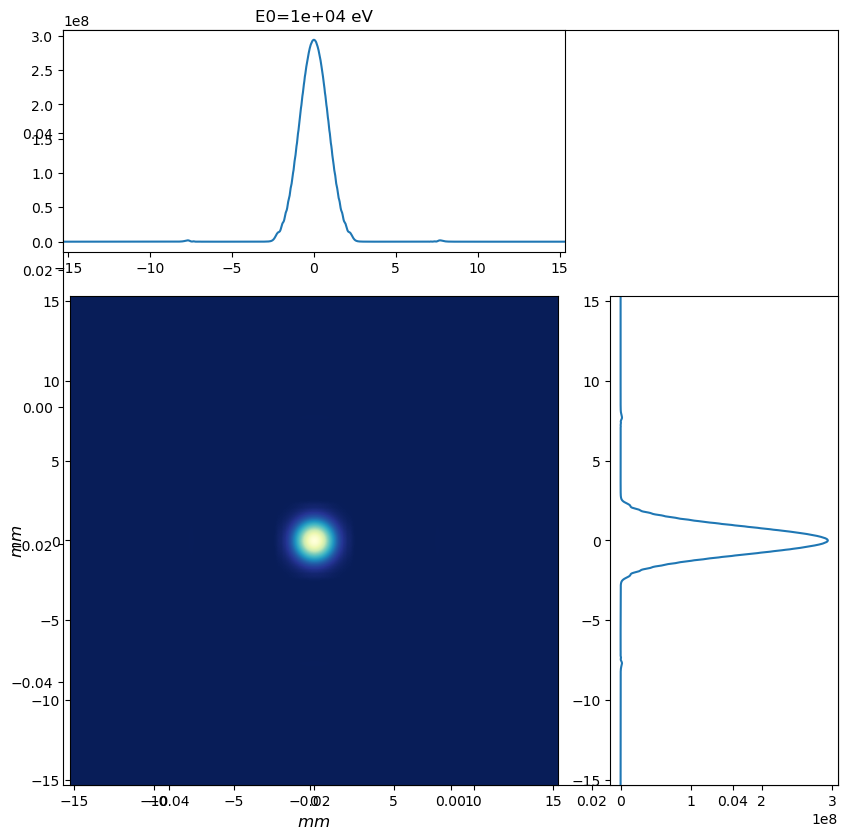

In [3]:
bl = Beamline()
D = Drift(50)
D.name = "drift1"
bl.append(D, propagation_parameters(1,1,1,1, mode = 'fraunhofer'))
bl.propagate(wfr)
plot_intensity_map(wfr)



In [12]:
bl.index

{'drift1': 0}

In [9]:
bl.get_element_properties('drift1')

{'L': 50, 'treat': 0, 'name': 'drift1'}

In [11]:
bl.edit_element_property('drift1', 'L', 45)
bl.get_element_properties('drift1')

{'L': 45, 'treat': 0, 'name': 'drift1'}

In [6]:
# ## properties
# wfr.wavelength

In [7]:
D.type

AttributeError: 'SRWLOptD' object has no attribute 'type'

In [ ]:
# from wpg.wpg_uti_math import gaussian
# from matplotlib import pyplot as plt

# axis = 'x'

# plt.plot(wfr.get_axis(axis), wfr.get_profile(axis))

# params = wfr.get_beam_width(axis)

# plt.plot(wfr.get_axis(axis), gaussian(wfr.get_axis(axis), *params),
#         linestyle = 'dotted')

In [ ]:
# from wpg.wpg_uti_math import gaussian
# from matplotlib import pyplot as plt

# axis = 't'

# plt.plot(wfr.get_axis(axis), wfr.get_profile(axis))

# params = wfr.get_beam_width(axis)

# plt.plot(wfr.get_axis(axis), gaussian(wfr.get_axis(axis), *params),
#         linestyle = 'dotted')